In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")


TensorFlow version: 2.21.0
Libraries imported successfully!


In [2]:
# Create a small text classification dataset

texts = [
    "I love this movie",
    "This movie is excellent",
    "The film was amazing",
    "I really enjoyed the movie",
    "The story was very good",
    "This is a wonderful film",
    "The movie was fantastic",
    "I liked the acting",
    "The film was enjoyable",
    "This movie is great",
    "I loved the story",
    "The acting was excellent",
    "This was a beautiful movie",
    "I enjoyed watching this film",
    "The movie was interesting",
    "I hate this movie",
    "This movie is terrible",
    "The film was boring",
    "I really disliked the movie",
    "The story was very bad",
    "This is a horrible film",
    "The movie was awful",
    "I disliked the acting",
    "The film was disappointing",
    "This movie is bad",
    "I hated the story",
    "The acting was terrible",
    "This was a boring movie",
    "I did not enjoy this film",
    "The movie was disappointing"
]

labels = [
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0
]

# Create DataFrame
df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print("Dataset created successfully!")
print("Number of samples:", len(df))

df.head()

Dataset created successfully!
Number of samples: 30


,text,label
0,I love this movie,1
1,This movie is excellent,1
2,The film was amazing,1
3,I really enjoyed the movie,1
4,The story was very good,1


In [3]:
# Split the dataset into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 24
Validation samples: 6


In [4]:
# Create Text Vectorization layer

max_words = 1000

vectorizer = layers.TextVectorization(
    max_tokens=max_words,
    output_mode="tf_idf"
)

# Learn the vocabulary from training text
vectorizer.adapt(X_train)

print("Text vectorization completed!")
print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Text vectorization completed!
Vocabulary size: 35


In [5]:
# Test the vectorizer

sample_text = ["I love this movie"]

vectorized_text = vectorizer(sample_text)

print("Original text:")
print(sample_text)

print("\nVectorized numerical features:")
print(vectorized_text.numpy())

print("\nNumber of features:", vectorized_text.shape[1])

Original text:
['I love this movie']

Vectorized numerical features:
[[0.        0.        1.0986123 0.        1.1574528 1.299283  0.
  0.        0.        0.        0.        0.        0.        0.
  0.        0.        0.        0.        0.        0.        0.
  0.        2.5649493 0.        0.        0.        0.        0.
  0.        0.        0.        0.        0.        0.        0.       ]]

Number of features: 35


In [7]:
# Model 1: Neural Network without regularization

model_1 = tf.keras.Sequential([
    layers.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 35)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 593 (2.32 KB)

 Trainable params: 593 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Convert training and validation data to NumPy arrays

X_train_np = X_train.to_numpy(dtype=str)
X_val_np = X_val.to_numpy(dtype=str)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)

print("Training data:", X_train_np.shape)
print("Validation data:", X_val_np.shape)

Training data: (24,)
Validation data: (6,)


In [11]:
# Convert text into numerical TF-IDF features first

X_train_vec = vectorizer(X_train.to_list()).numpy()
X_val_vec = vectorizer(X_val.to_list()).numpy()

y_train_np = y_train.to_numpy(dtype="float32")
y_val_np = y_val.to_numpy(dtype="float32")

print("Training features shape:", X_train_vec.shape)
print("Validation features shape:", X_val_vec.shape)

Training features shape: (24, 35)
Validation features shape: (6, 35)


In [12]:
# Model 1: Without Regularization

model_1 = tf.keras.Sequential([
    layers.Input(shape=(X_train_vec.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 593 (2.32 KB)

 Trainable params: 593 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train Model 1

history_1 = model_1.fit(
    X_train_vec,
    y_train_np,
    validation_data=(X_val_vec, y_val_np),
    epochs=20,
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3750 - loss: 0.8164 - val_accuracy: 0.6667 - val_loss: 0.6316
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3750 - loss: 0.8106 - val_accuracy: 0.6667 - val_loss: 0.6326
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.3750 - loss: 0.8048 - val_accuracy: 0.6667 - val_loss: 0.6336
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3750 - loss: 0.7991 - val_accuracy: 0.6667 - val_loss: 0.6346
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3750 - loss: 0.7935 - val_accuracy: 0.6667 - val_loss: 0.6356
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3750 - loss: 0.7880 - val_accuracy: 0.6667 - val_loss: 0.6366
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3750 - loss: 0.7825 - val_accuracy: 0.6667 - val_loss: 0.6376
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3750 - loss: 0.7772 - val_accuracy: 0.6667 - val_loss: 0.6386
Ep

In [14]:
# Store Model 1 final results

model_1_results = {
    "Model": "Without Regularization",
    "Training Accuracy": history_1.history["accuracy"][-1],
    "Validation Accuracy": history_1.history["val_accuracy"][-1],
    "Training Loss": history_1.history["loss"][-1],
    "Validation Loss": history_1.history["val_loss"][-1]
}

print(model_1_results)

{'Model': 'Without Regularization', 'Training Accuracy': 0.4166666567325592, 'Validation Accuracy': 0.6666666865348816, 'Training Loss': 0.7193260788917542, 'Validation Loss': 0.650493323802948}


In [16]:
# Model 2: Neural Network with Dropout

model_2 = tf.keras.Sequential([
    layers.Input(shape=(X_train_vec.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 593 (2.32 KB)

 Trainable params: 593 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train Model 2 with Dropout

history_2 = model_2.fit(
    X_train_vec,
    y_train_np,
    validation_data=(X_val_vec, y_val_np),
    epochs=20,
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 917ms/step - accuracy: 0.3333 - loss: 0.9494 - val_accuracy: 0.5000 - val_loss: 0.8271
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3750 - loss: 0.8247 - val_accuracy: 0.5000 - val_loss: 0.8278
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4583 - loss: 0.8207 - val_accuracy: 0.5000 - val_loss: 0.8274
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5417 - loss: 0.7591 - val_accuracy: 0.5000 - val_loss: 0.8273
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3750 - loss: 0.8759 - val_accuracy: 0.5000 - val_loss: 0.8269
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5000 - loss: 0.9102 - val_accuracy: 0.5000 - val_loss: 0.8261
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4583 - loss: 0.8831 - val_accuracy: 0.5000 - val_loss: 0.8253
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5000 - loss: 0.7487 - val_accuracy: 0.5000 - val_loss: 0.8247

In [18]:
# Model 3: Neural Network with L2 Regularization

model_3 = tf.keras.Sequential([
    layers.Input(shape=(X_train_vec.shape[1],)),
    layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.01)
    ),
    layers.Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=regularizers.l2(0.01)
    )
])

model_3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 593 (2.32 KB)

 Trainable params: 593 (2.32 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train Model 3 with L2 Regularization

history_3 = model_3.fit(
    X_train_vec,
    y_train_np,
    validation_data=(X_val_vec, y_val_np),
    epochs=20,
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step - accuracy: 0.3333 - loss: 1.0578 - val_accuracy: 0.5000 - val_loss: 0.8867
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3333 - loss: 1.0501 - val_accuracy: 0.5000 - val_loss: 0.8862
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.3333 - loss: 1.0424 - val_accuracy: 0.5000 - val_loss: 0.8858
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3333 - loss: 1.0348 - val_accuracy: 0.5000 - val_loss: 0.8854
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3333 - loss: 1.0274 - val_accuracy: 0.5000 - val_loss: 0.8851
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3333 - loss: 1.0200 - val_accuracy: 0.5000 - val_loss: 0.8848
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3333 - loss: 1.0127 - val_accuracy: 0.5000 - val_loss: 0.8845
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3333 - loss: 1.0056 - val_accuracy: 0.5000 - val_loss: 0.8842

In [20]:
# Compare all three models

comparison = pd.DataFrame({
    "Model": [
        "Without Regularization",
        "Dropout",
        "L2 Regularization"
    ],
    "Training Accuracy": [
        history_1.history["accuracy"][-1],
        history_2.history["accuracy"][-1],
        history_3.history["accuracy"][-1]
    ],
    "Validation Accuracy": [
        history_1.history["val_accuracy"][-1],
        history_2.history["val_accuracy"][-1],
        history_3.history["val_accuracy"][-1]
    ],
    "Training Loss": [
        history_1.history["loss"][-1],
        history_2.history["loss"][-1],
        history_3.history["loss"][-1]
    ],
    "Validation Loss": [
        history_1.history["val_loss"][-1],
        history_2.history["val_loss"][-1],
        history_3.history["val_loss"][-1]
    ]
})

comparison

,Model,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,Without Regularization,0.416667,0.666667,0.719326,0.650493
1,Dropout,0.500000,0.500000,0.772915,0.817947
2,L2 Regularization,0.416667,0.500000,0.928412,0.883050


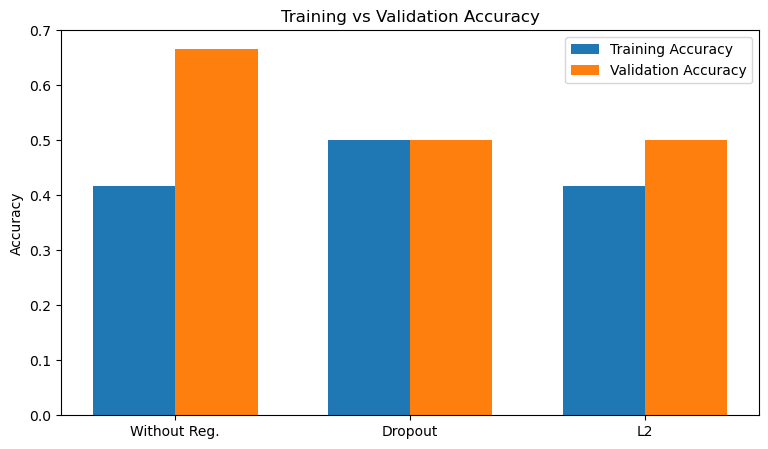

In [21]:
# Accuracy comparison

models = ["Without Reg.", "Dropout", "L2"]

train_accuracy = [
    history_1.history["accuracy"][-1],
    history_2.history["accuracy"][-1],
    history_3.history["accuracy"][-1]
]

val_accuracy = [
    history_1.history["val_accuracy"][-1],
    history_2.history["val_accuracy"][-1],
    history_3.history["val_accuracy"][-1]
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, train_accuracy, width, label="Training Accuracy")
plt.bar(x + width/2, val_accuracy, width, label="Validation Accuracy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

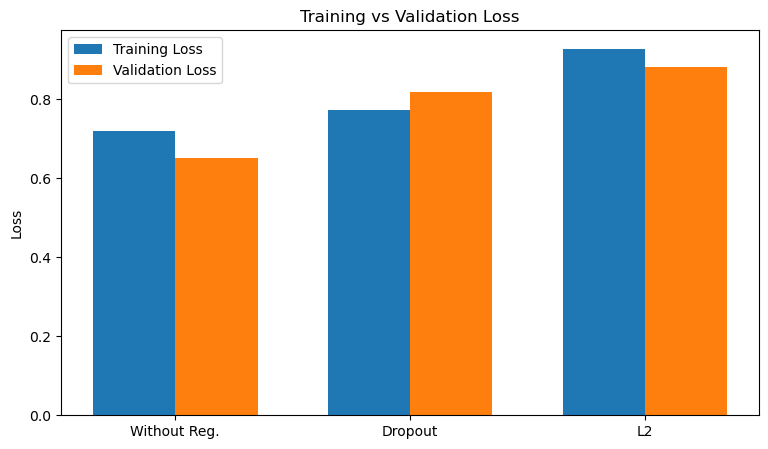

In [22]:
# Loss comparison

train_loss = [
    history_1.history["loss"][-1],
    history_2.history["loss"][-1],
    history_3.history["loss"][-1]
]

val_loss = [
    history_1.history["val_loss"][-1],
    history_2.history["val_loss"][-1],
    history_3.history["val_loss"][-1]
]

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, train_loss, width, label="Training Loss")
plt.bar(x + width/2, val_loss, width, label="Validation Loss")

plt.xticks(x, models)
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [23]:
# Test the models with new unseen text

new_texts = [
    "The movie was really wonderful",
    "I hated this terrible movie",
    "The film was very enjoyable",
    "The story was boring and bad"
]

# Convert new text into TF-IDF numerical features
new_text_features = vectorizer(new_texts).numpy()

# Predictions from all three models
pred_1 = model_1.predict(new_text_features)
pred_2 = model_2.predict(new_text_features)
pred_3 = model_3.predict(new_text_features)

print("New Text Predictions\n")

for i, text in enumerate(new_texts):
    print("Text:", text)
    print("Without Regularization:", 
          "Positive" if pred_1[i][0] >= 0.5 else "Negative")
    print("Dropout:", 
          "Positive" if pred_2[i][0] >= 0.5 else "Negative")
    print("L2 Regularization:", 
          "Positive" if pred_3[i][0] >= 0.5 else "Negative")
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
New Text Predictions

Text: The movie was really wonderful
Without Regularization: Negative
Dropout: Positive
L2 Regularization: Positive
------------------------------------------------------------
Text: I hated this terrible movie
Without Regularization: Negative
Dropout: Positive
L2 Regularization: Negative
------------------------------------------------------------
Text: The film was very enjoyable
Without Regularization: Negative
Dropout: Positive
L2 Regularization: Negative
------------------------------------------------------------
Text: The story was boring and bad
Without Regularization: Negative
Dropout: Positive
L2 Regularization: Positive
------------------------------------------------------------


In [24]:
# Evaluate all three models

results_1 = model_1.evaluate(X_val_vec, y_val_np, verbose=0)
results_2 = model_2.evaluate(X_val_vec, y_val_np, verbose=0)
results_3 = model_3.evaluate(X_val_vec, y_val_np, verbose=0)

print("Model 1 - Without Regularization")
print("Loss:", results_1[0])
print("Accuracy:", results_1[1])

print("\nModel 2 - Dropout")
print("Loss:", results_2[0])
print("Accuracy:", results_2[1])

print("\nModel 3 - L2 Regularization")
print("Loss:", results_3[0])
print("Accuracy:", results_3[1])

Model 1 - Without Regularization
Loss: 0.650493323802948
Accuracy: 0.6666666865348816

Model 2 - Dropout
Loss: 0.8179466128349304
Accuracy: 0.5

Model 3 - L2 Regularization
Loss: 0.8830496668815613
Accuracy: 0.5
